In [1]:
!pip install gymnasium[classic-control]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 65.0 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
env = gym.make("CartPole-v1")

print("Environment Created Successfully!")

Environment Created Successfully!


In [4]:
print("Observation Space:")
print(env.observation_space)

print("\nAction Space:")
print(env.action_space)

Observation Space:
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Action Space:
Discrete(2)


In [5]:
state, info = env.reset()

print("Initial State:")

print(state)

Initial State:
[-0.03848385  0.0140265   0.02588221  0.04063023]


In [6]:
episodes = 5

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    done = False

    while not done:

        action = env.action_space.sample()

        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        done = terminated or truncated

    print(f"Episode {episode+1} Reward = {total_reward}")

Episode 1 Reward = 31.0
Episode 2 Reward = 9.0
Episode 3 Reward = 37.0
Episode 4 Reward = 66.0
Episode 5 Reward = 17.0


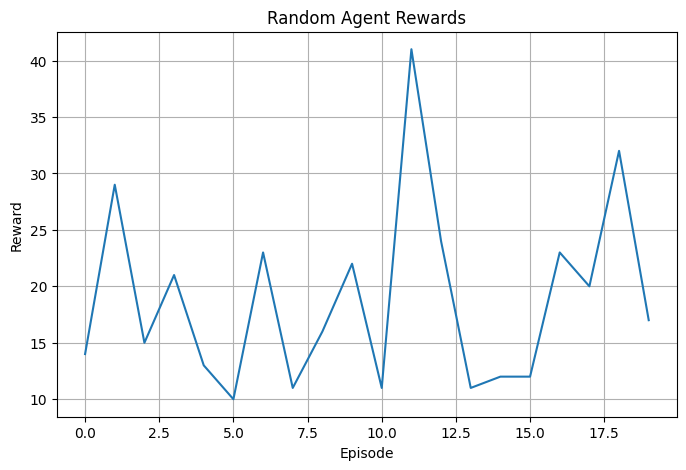

In [7]:
rewards = []

for episode in range(20):

    state, info = env.reset()

    total_reward = 0

    done = False

    while not done:

        action = env.action_space.sample()

        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        done = terminated or truncated

    rewards.append(total_reward)

plt.figure(figsize=(8,5))

plt.plot(rewards)

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.title("Random Agent Rewards")

plt.grid(True)

plt.show()

In [8]:
bins = [
    np.linspace(-4.8, 4.8, 20),
    np.linspace(-4, 4, 20),
    np.linspace(-0.418, 0.418, 20),
    np.linspace(-4, 4, 20)
]

def discretize_state(state):
    state_index = []

    for i in range(len(state)):
        state_index.append(np.digitize(state[i], bins[i]))

    return tuple(state_index)

# Initialize Q-table
q_table = np.zeros((21, 21, 21, 21, env.action_space.n))

print("Q-Table Shape:", q_table.shape)

Q-Table Shape: (21, 21, 21, 21, 2)


In [9]:
learning_rate = 0.1
discount_factor = 0.99

epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 500

print("Hyperparameters Initialized!")

Hyperparameters Initialized!


In [10]:
episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()

    state = discretize_state(state)

    done = False

    total_reward = 0

    while not done:

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        next_state = discretize_state(next_state)

        done = terminated or truncated

        best_next = np.max(q_table[next_state])

        q_table[state + (action,)] += learning_rate * (
            reward +
            discount_factor * best_next -
            q_table[state + (action,)]
        )

        state = next_state

        total_reward += reward

    episode_rewards.append(total_reward)

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training Completed Successfully!")

Training Completed Successfully!


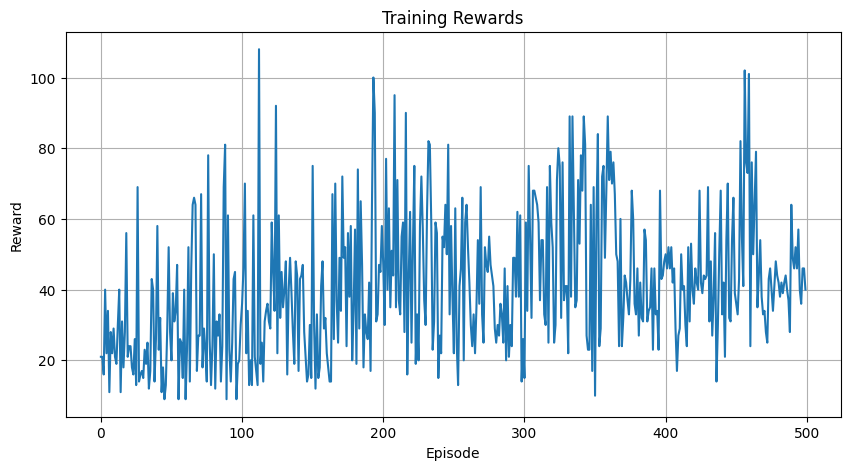

In [11]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.title("Training Rewards")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

In [12]:
test_rewards = []

for episode in range(20):

    state, info = env.reset()

    state = discretize_state(state)

    done = False

    total_reward = 0

    while not done:

        action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        state = discretize_state(next_state)

        total_reward += reward

        done = terminated or truncated

    test_rewards.append(total_reward)

print("Average Reward:", np.mean(test_rewards))

Average Reward: 40.6


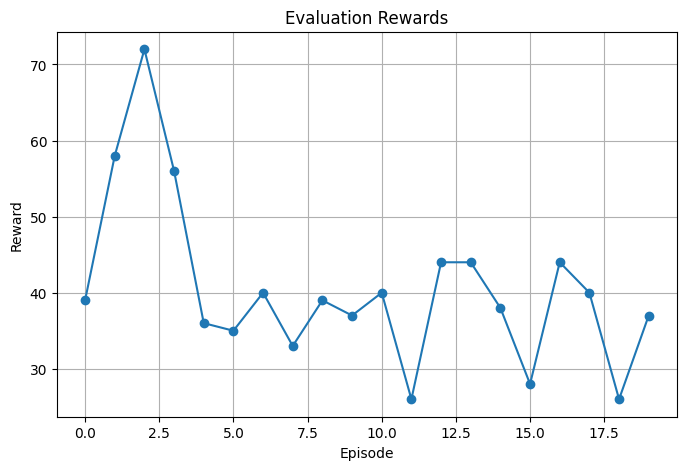

In [13]:
plt.figure(figsize=(8,5))

plt.plot(test_rewards, marker='o')

plt.title("Evaluation Rewards")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

In [14]:
print("Maximum Reward :", np.max(test_rewards))
print("Minimum Reward :", np.min(test_rewards))
print("Average Reward :", np.mean(test_rewards))

Maximum Reward : 72.0
Minimum Reward : 26.0
Average Reward : 40.6


# Observations

1. The Q-Learning agent gradually improved its performance over training episodes.

2. The average reward increased as the agent learned better actions through exploration and exploitation.

3. The evaluation results show that the trained agent balanced the pole for longer durations compared to the random agent.

4. Reinforcement Learning enables an agent to learn optimal behavior through interaction with the environment without requiring labeled training data.



## Conclusion

The Cart-Pole Reinforcement Learning project successfully trained an intelligent agent using the Q-Learning algorithm to balance a pole on a moving cart. The agent learned through repeated interactions with the environment by receiving rewards for keeping the pole balanced. During training, the agent gradually improved its decision-making ability by updating the Q-table based on its experiences. The evaluation results showed that the trained agent achieved significantly higher rewards than a random agent, demonstrating successful learning. This project highlights the effectiveness of Reinforcement Learning in solving sequential decision-making problems and illustrates how agents can learn optimal actions without requiring labeled datasets through continuous interaction with the environment.

## Key Findings

- The Q-Learning agent successfully learned to balance the pole through repeated interactions with the environment.
- The agent's performance improved as training progressed, resulting in higher average rewards.
- Reinforcement Learning enables autonomous learning without requiring labeled training data.

## Importance of Reinforcement Learning

- Reinforcement Learning enables intelligent agents to learn optimal actions by interacting with an environment and receiving rewards, making it suitable for robotics, autonomous systems, and game-playing applications.

## One Advantage of Q-Learning

- Q-Learning is a model-free reinforcement learning algorithm that can learn the optimal policy without requiring prior knowledge of the environment.

## One Limitation of Q-Learning

- Q-Learning can become inefficient for environments with very large or continuous state spaces because the Q-table grows rapidly.